In [1]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Step 2: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")


In [3]:
# Step 3: Load cleaned colorectal cancer dataset

path = "/content/drive/MyDrive/colorectal_cancer_prediction_cleaned_imputed.csv"
df = pd.read_csv(path)


# Preview first rows
df.head()


,Patient_ID,Age,Gender,Race,Region,Urban_or_Rural,Socioeconomic_Status,Family_History,Previous_Cancer_History,Stage_at_Diagnosis,...,Insurance_Coverage,Time_to_Diagnosis,Treatment_Access,Chemotherapy_Received,Radiotherapy_Received,Surgery_Received,Follow_Up_Adherence,Survival_Status,Recurrence,Time_to_Recurrence
0,1,71,Male,Other,Europe,Urban,Middle,Yes,No,III,...,Yes,Delayed,Good,Yes,No,No,Good,Survived,No,16
1,2,34,Female,Black,North America,Urban,Middle,No,No,I,...,No,Timely,Good,No,Yes,Yes,Poor,Deceased,No,28
2,3,80,Female,White,North America,Urban,Middle,No,No,III,...,Yes,Timely,Limited,No,Yes,Yes,Good,Survived,No,26
3,4,40,Male,Black,North America,Rural,Low,No,No,I,...,Yes,Delayed,Limited,Yes,No,Yes,Poor,Deceased,No,44
4,5,43,Female,White,Europe,Urban,High,Yes,No,III,...,No,Delayed,Good,Yes,No,Yes,Poor,Deceased,Yes,20


In [4]:
# Step 4: Inspect structure and metadata
print("Dataset Shape:", df.shape)
print("\nColumn Types:\n", df.dtypes)

# Summary statistics
df.describe(include='all')


Dataset Shape: (89945, 30)

Column Types:
 Patient_ID                   int64
Age                          int64
Gender                      object
Race                        object
Region                      object
Urban_or_Rural              object
Socioeconomic_Status        object
Family_History              object
Previous_Cancer_History     object
Stage_at_Diagnosis          object
Tumor_Aggressiveness        object
Colonoscopy_Access          object
Screening_Regularity        object
Diet_Type                   object
BMI                        float64
Physical_Activity_Level     object
Smoking_Status              object
Alcohol_Consumption         object
Red_Meat_Consumption        object
Fiber_Consumption           object
Insurance_Coverage          object
Time_to_Diagnosis           object
Treatment_Access            object
Chemotherapy_Received       object
Radiotherapy_Received       object
Surgery_Received            object
Follow_Up_Adherence         object
Survival_Sta

,Patient_ID,Age,Gender,Race,Region,Urban_or_Rural,Socioeconomic_Status,Family_History,Previous_Cancer_History,Stage_at_Diagnosis,...,Insurance_Coverage,Time_to_Diagnosis,Treatment_Access,Chemotherapy_Received,Radiotherapy_Received,Surgery_Received,Follow_Up_Adherence,Survival_Status,Recurrence,Time_to_Recurrence
count,89945.000000,89945.000000,89945,89945,89945,89945,89945,89945,89945,89945,...,89945,89945,89945,89945,89945,89945,89945,89945,89945,89945.000000
unique,NaN,NaN,2,5,5,2,3,2,2,4,...,2,2,2,2,2,2,2,2,2,NaN
top,NaN,NaN,Male,White,North America,Urban,Middle,No,No,II,...,Yes,Timely,Good,Yes,No,Yes,Good,Survived,No,NaN
freq,NaN,NaN,49369,44887,31537,62990,45088,67372,80985,26869,...,72118,54080,62897,45067,53952,62879,54041,67341,62975,NaN
mean,44973.000000,54.332892,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.543299
std,25965.029318,20.182220,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.268440
min,1.000000,20.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,22487.000000,37.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.000000
50%,44973.000000,54.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.000000
75%,67459.000000,72.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.000000


In [5]:
# Step 5: Missingness check
missing_values = df.isnull().sum()
missing_values[missing_values > 0]


,0


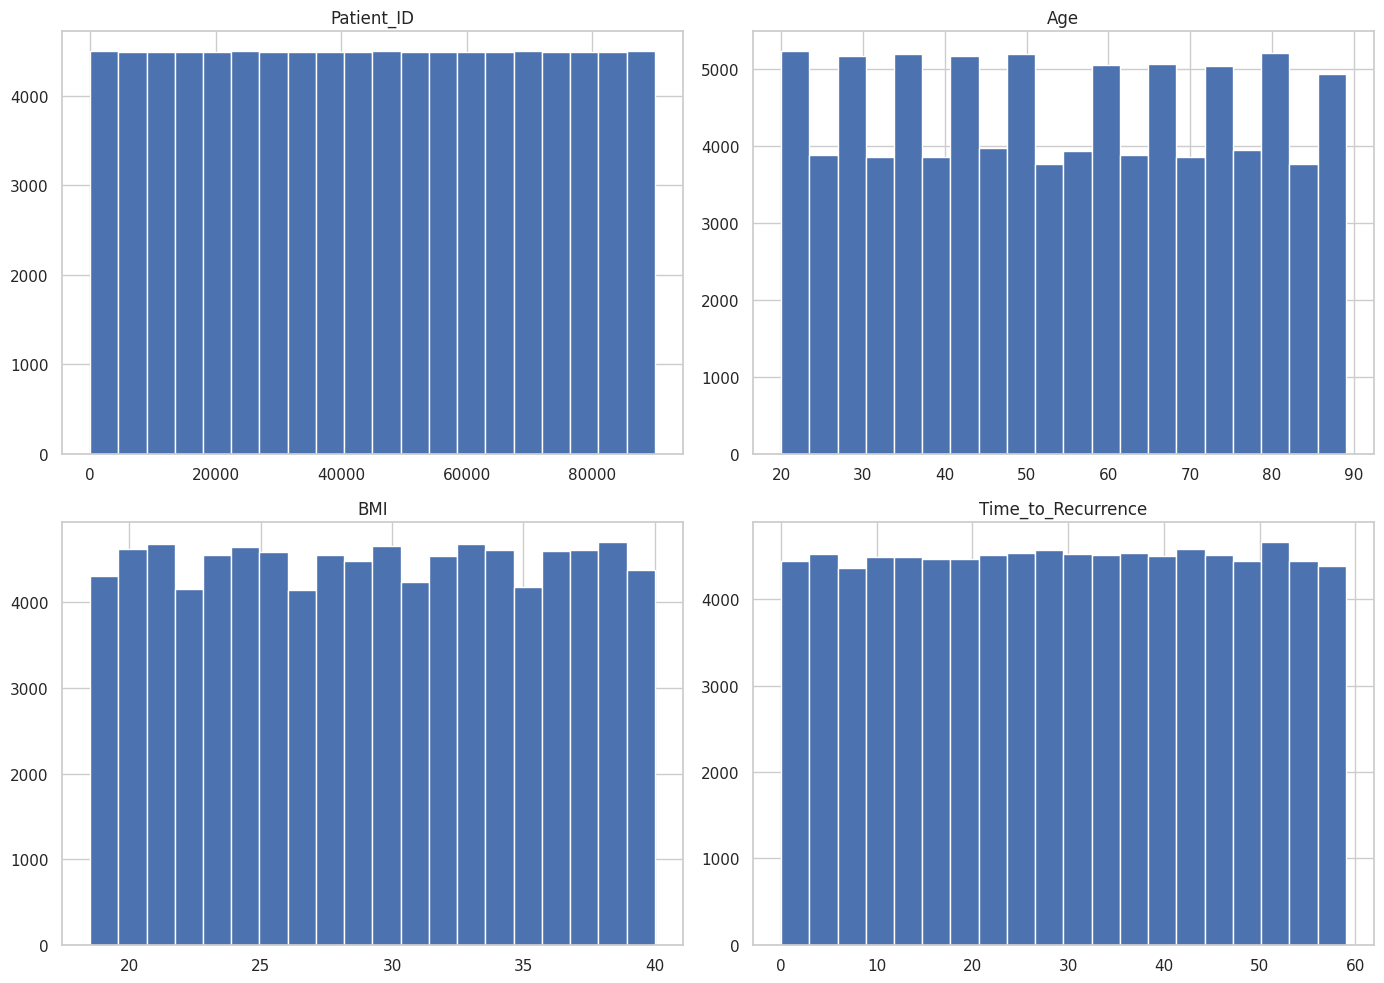

In [7]:
import os

# Step 6: Distribution plots for numeric variables
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

df[numeric_cols].hist(figsize=(14, 10), bins=20)
plt.tight_layout()
plt.show()

# Create the directory if it doesn't exist
os.makedirs('reports/figures', exist_ok=True)
plt.savefig("reports/figures/Distribution plots.png", dpi=300)
plt.close()

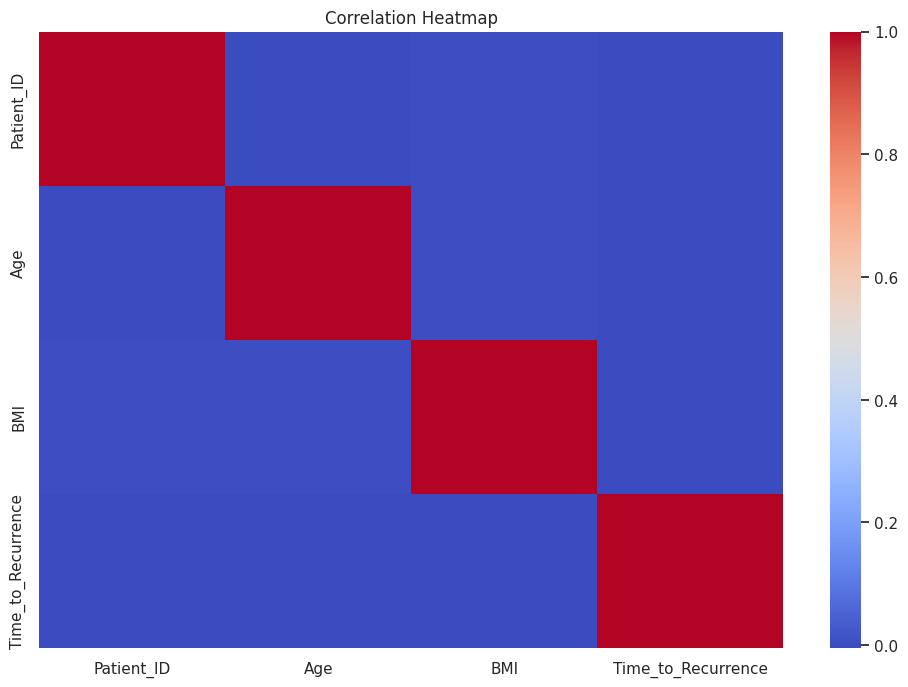

In [8]:
import numpy as np
# Step 7: Correlation heatmap for numeric variables
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=np.number).corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap")
plt.show()
plt.savefig("reports/figures/Correlation Heatmap.png", dpi=300)
plt.close()

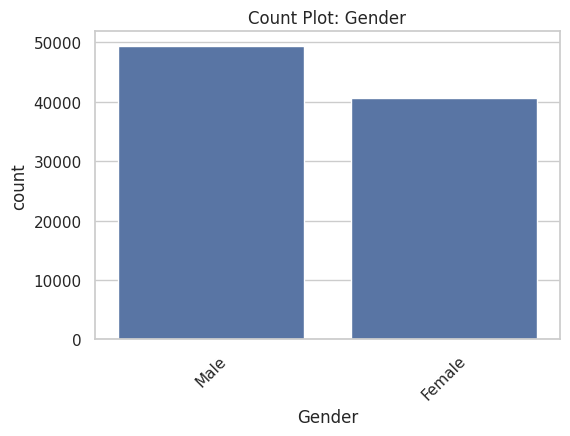

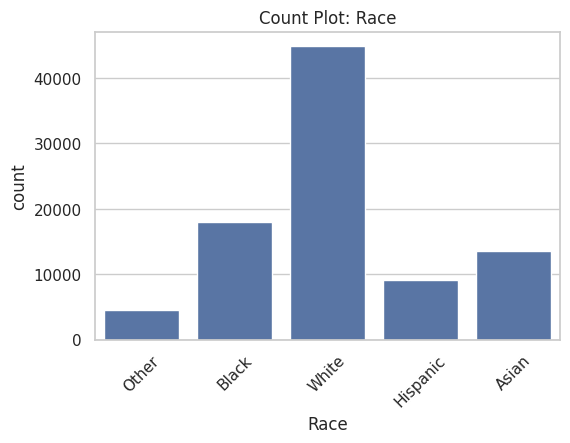

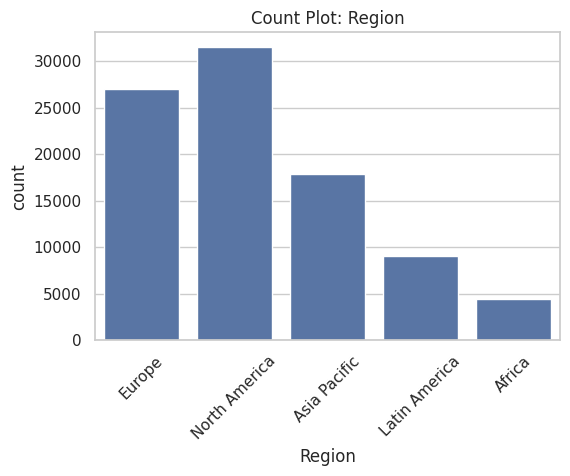

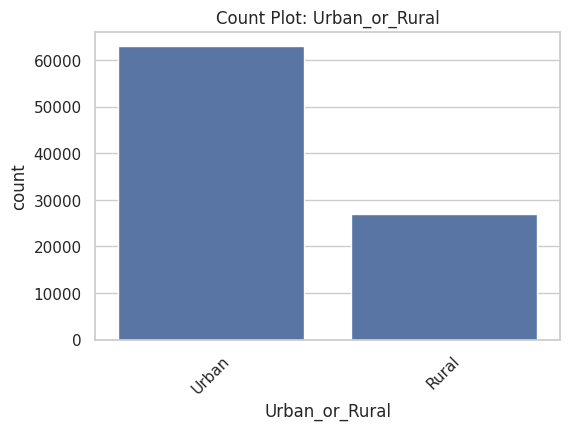

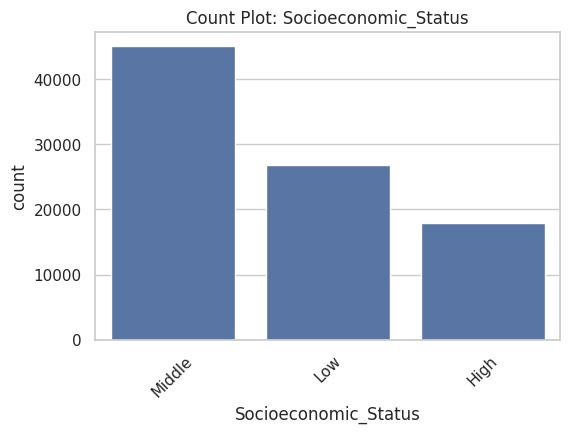

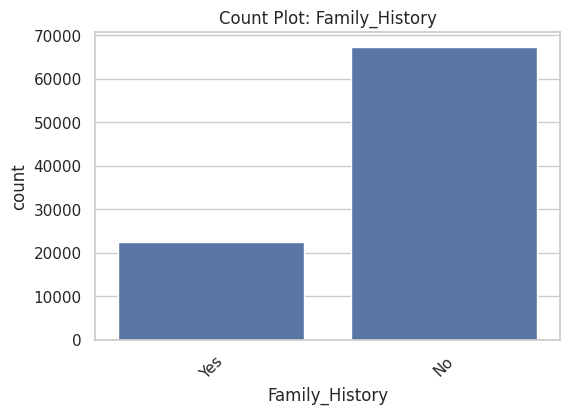

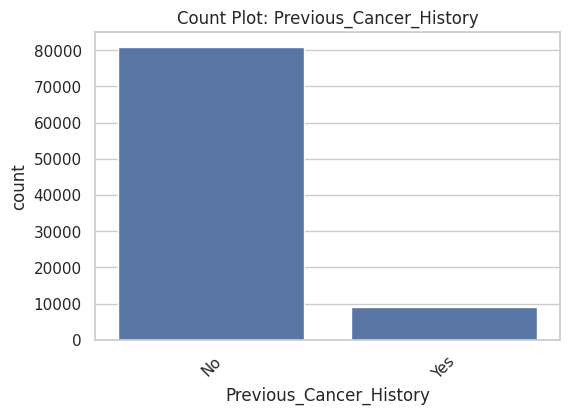

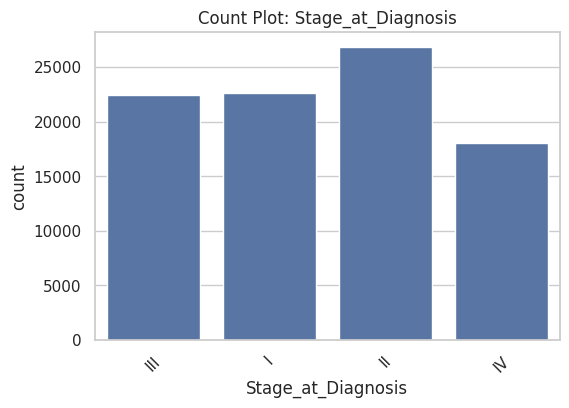

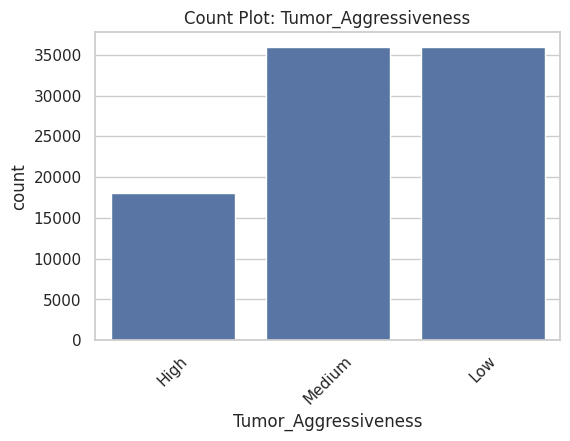

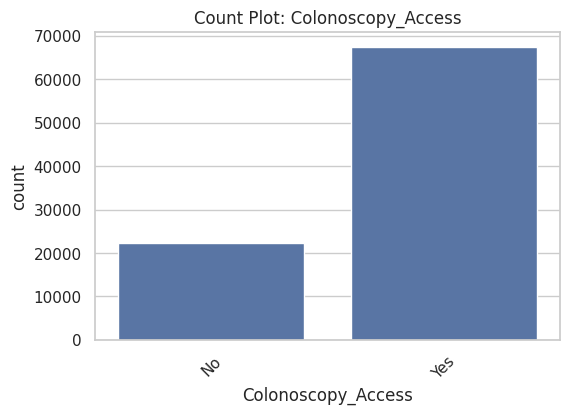

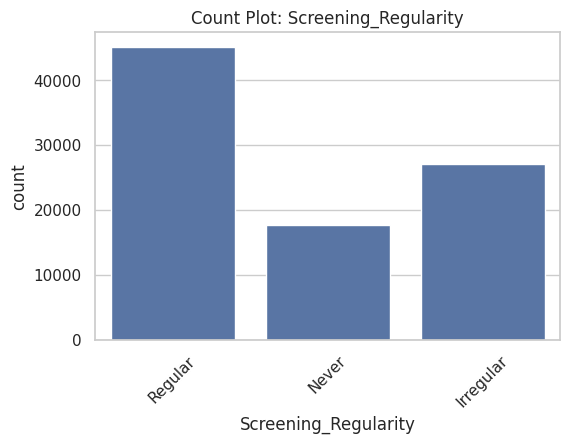

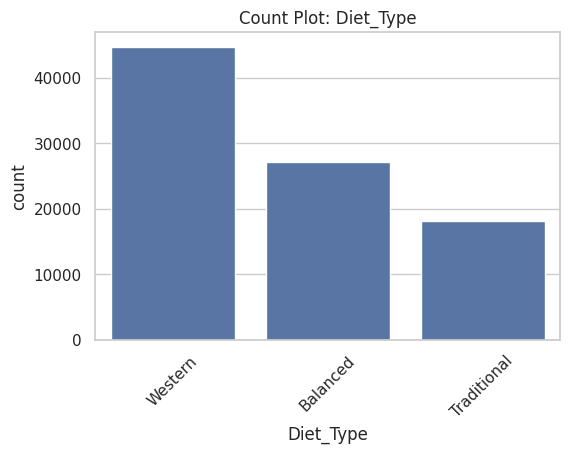

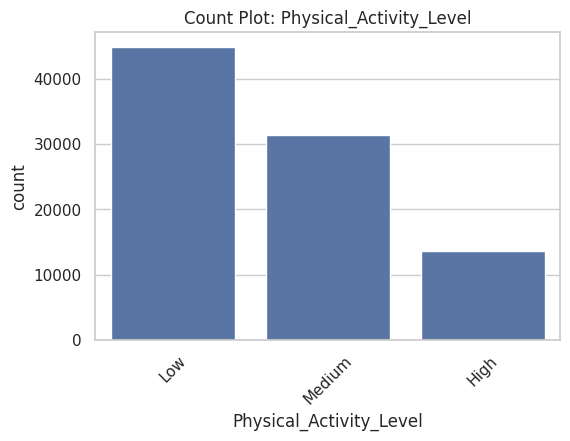

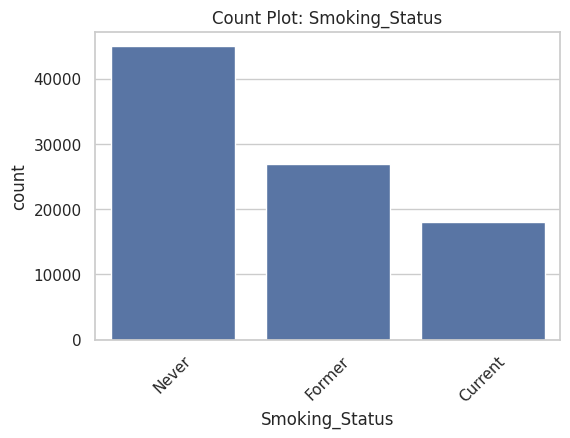

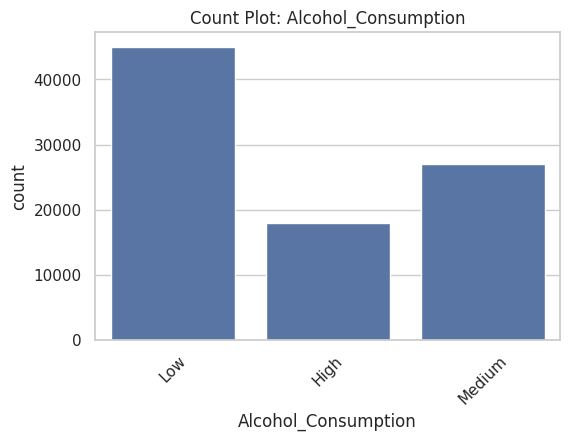

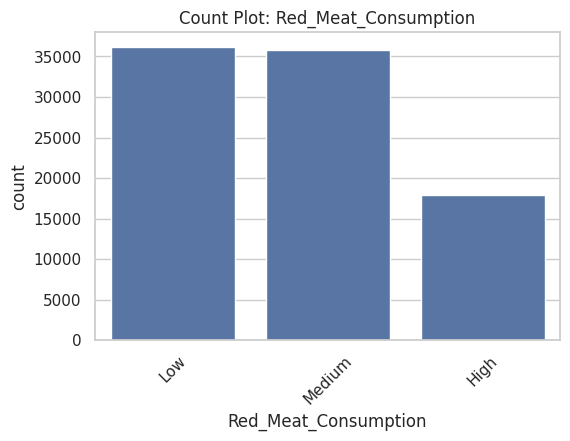

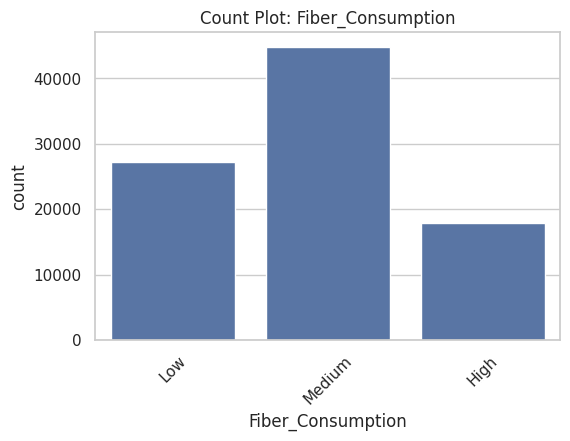

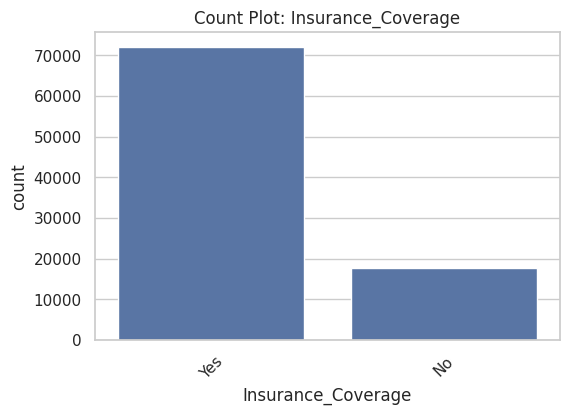

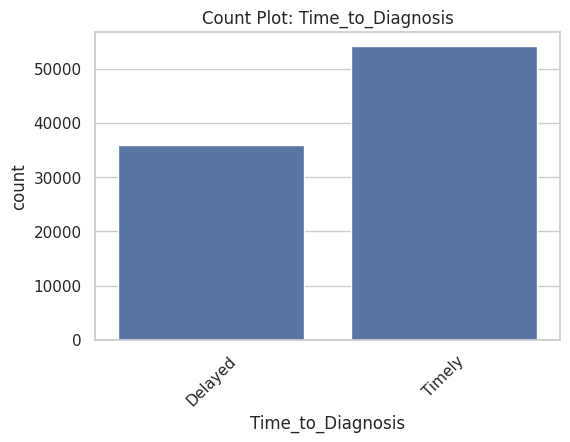

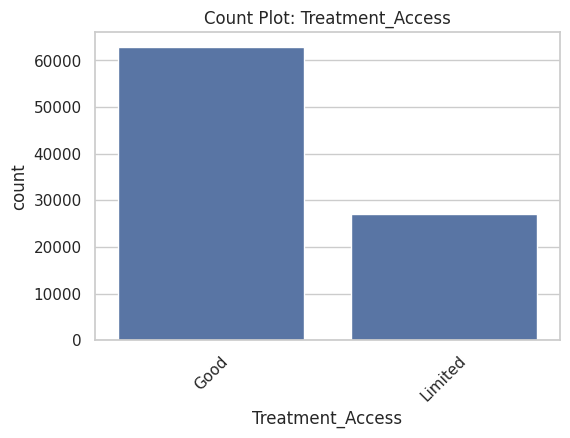

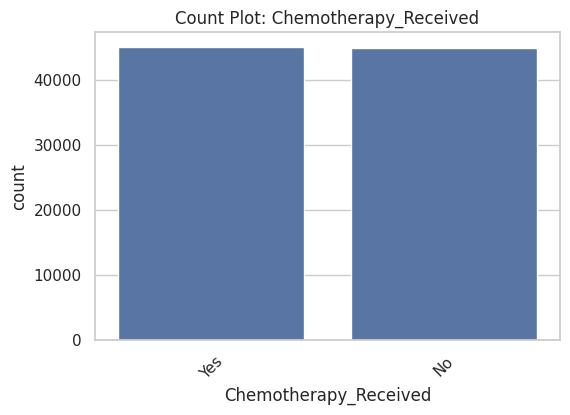

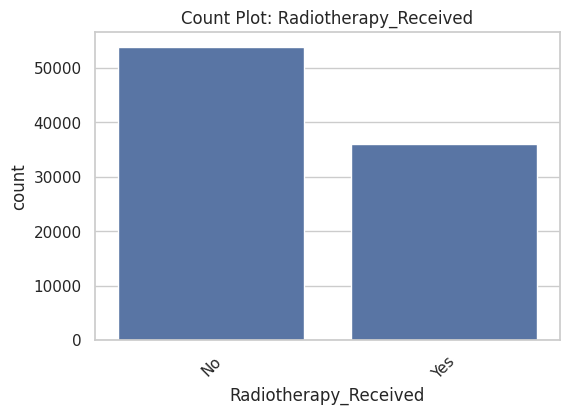

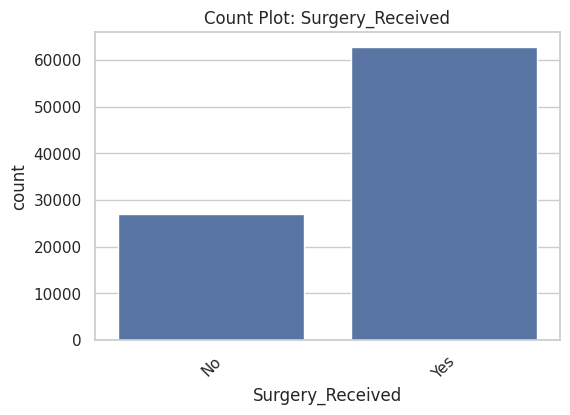

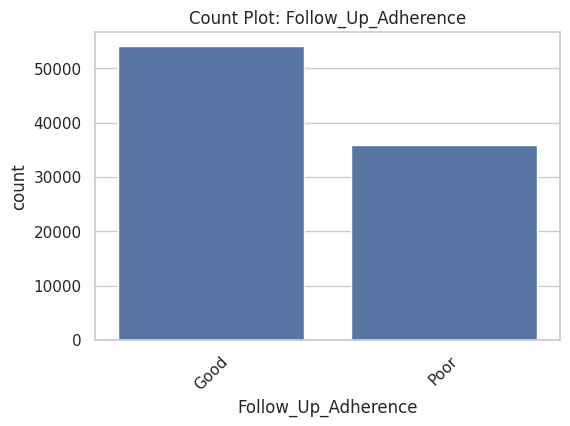

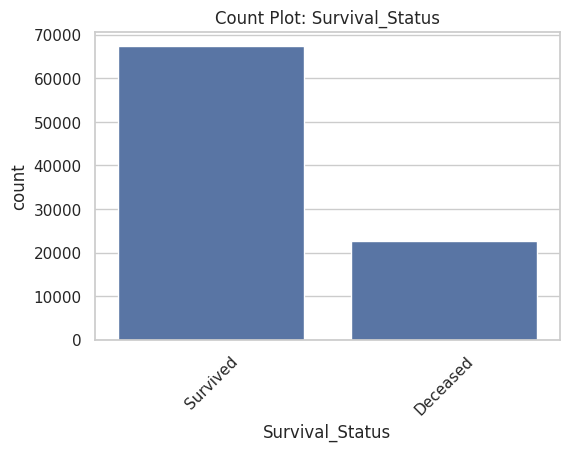

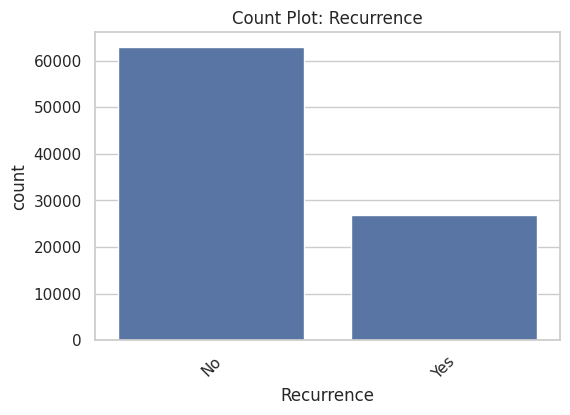

In [9]:
# Step 8: Count plots for categorical variables
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col)
    plt.title(f"Count Plot: {col}")
    plt.xticks(rotation=45)
    plt.show()
    plt.savefig("reports/figures/Count plots.png", dpi=300)
    plt.close()


In [10]:
# Step 9: Save updated dataset if modifications were made
output_path = "/content/drive/MyDrive/colorectal_cancer_prediction/colorectal_cancer_prediction_updated.csv"
df.to_csv(output_path, index=False)
